In [1]:
# Basic imports and setup
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import corner

# Import the new data loader and plotting functions
from analyze_modules import ChelioRun

# get viridis colormap
cmap = plt.get_cmap('viridis')
cmap.set_bad(color='black')
plt.rcParams['figure.dpi'] = 200

In [2]:
def set_white(ax):
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    ax.tick_params(axis='x', colors='white', which='both')  # Set color for both major and minor ticks
    ax.tick_params(axis='y', colors='white', which='both')  # Set color for both major and minor ticks

def increase_size(ax, linewidth=3, fontsize=14, legendcols=1, legendloc='best'):
    for l in ax.lines:
        l.set_linewidth(linewidth)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(linewidth)
    ax.set_title(ax.get_title(), fontsize=fontsize)
    ax.xaxis.set_tick_params(width=linewidth)
    ax.yaxis.set_tick_params(width=linewidth)
    ax.xaxis.label.set_size(fontsize)
    ax.yaxis.label.set_size(fontsize)
    ax.xaxis.set_tick_params(labelsize=fontsize)
    ax.yaxis.set_tick_params(labelsize=fontsize)
    if legendloc != 'no':
        ax.legend(fontsize=fontsize, ncols=legendcols, loc=legendloc)

In [3]:
# Define parameters for the matrix
folder = '../output/Atmodeller/'

Tints = np.array([50, 100, 150, 200])
Tmelts = np.array([1000, 2000])
Hoceans = np.array([0.1, 1.0, 10.0])
CtoHs = np.array([0.1, 1.0, 10.0])
NtoCs = np.array([0.01, 0.1, 1.0])
fO2s = np.array([-3, 0, 3])

var_params = [Tmelts, Hoceans, CtoHs, NtoCs, fO2s]
var_param_names = ['Tmelt', 'Hocean', 'CtoH', 'NtoC', 'fO2']
param_log = [False, True, True, True, False]

# Define the parameter grid
param_grid = np.meshgrid(*var_params)
print(param_grid[0].shape)

# Flatten the parameter grid
param_grid = np.array([p.flatten() for p in param_grid])
print(param_grid.shape)

(3, 2, 3, 3, 3)
(5, 162)


In [15]:
Tint = 50
runs = []

for i in range(param_grid.shape[1]):
    ntoc_str = f"{param_grid[3, i]:.1f}" if param_grid[3, i] >= 1.0 else f"{param_grid[3, i]:.1g}"
    run_name = f"Earth_Tint={Tint}_Tmelt={param_grid[0, i]:.0f}_Hocean={param_grid[1, i]:.1f}_CtoH={param_grid[2, i]:.1f}_NtoC={ntoc_str}_fO2={param_grid[4, i]:.0f}"
    #print(run_name)
    run = ChelioRun(folder, run_name)
    run.read_data()
    run.convert_to_vmr()
    runs.append(run)

converged_mask = np.array([run.final_convergence_status for run in runs])
converged = converged_mask.sum()
print(f"Number of converged runs: {converged}, {converged/len(runs)*100:.2f}%")

Number of converged runs: 144, 88.89%


In [16]:
# get outgassed data

vmrs = {}
Psurfs = np.zeros(len(runs))
PTs = []

for i, run in enumerate(runs):
    run_name = run.run_name + '_outgassed'
    p_file = folder + run_name + '/P_BOA.dat'
    vmrs_file = folder + run_name + '/species.dat'
    try:
        with open(p_file, 'r') as f:
            Psurfs[i] = float(f.readline())*1e-6
        with open(vmrs_file, 'r') as f:
            for j, line in enumerate(f):
                if j != 0 and line != '\n':
                    line = line.split()
                    if line[0] == 'CIA_N2N2':
                        mol, vmr = 'N2', float(line[-1].split('&')[0])
                    elif line[0][:3] == 'CIA':
                        continue
                    else:
                        mol, vmr = line[0], float(line[-1])
                    
                    if mol not in vmrs:
                        vmrs[mol] = []
                    vmrs[mol].append(vmr)
        try:
            pt_file = folder + run_name + f'/{run_name}_tp_cut.dat'
            pt = np.loadtxt(pt_file, skiprows=2, usecols=(2,1))
            pt[:,0] *= 1e-6 # dyn/cm^2 to bar
            PTs.append(pt)
        except:
            PTs.append(np.array([[np.nan, np.nan]]))
    except:
        Psurfs[i] = np.nan
        PTs.append(np.array([[np.nan, np.nan]]))

for mol in vmrs.keys():
    vmr = np.array(vmrs[mol])
    vmrs[mol] = np.empty_like(Psurfs)
    vmrs[mol][:] = np.nan
    mask = np.logical_not(np.isnan(Psurfs))
    vmrs[mol][mask] = vmr

converged 144
low P 18
GGchem fails 129


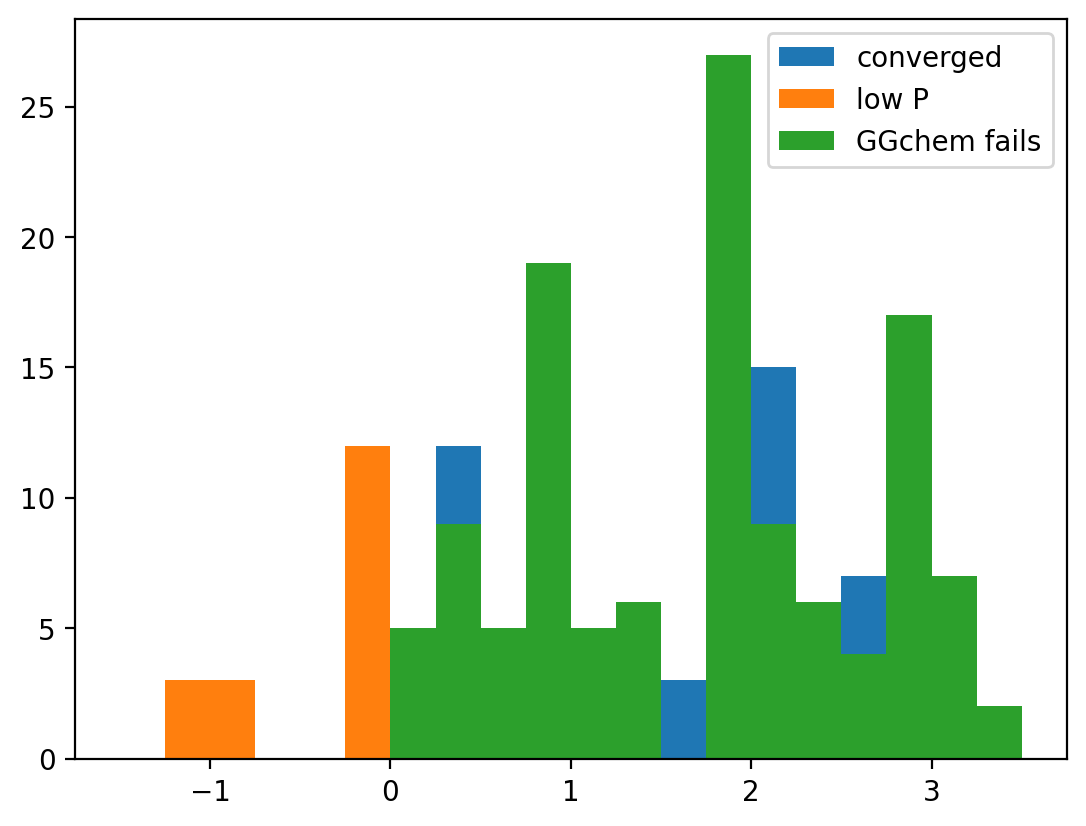

In [17]:
mask_lowP = Psurfs < 1e0
mask_noConv = np.logical_and(np.logical_not(converged_mask), np.logical_not(mask_lowP))
mask_noConv = np.logical_and(mask_noConv, np.logical_not(np.isnan(Psurfs)))
mask_Tconst = np.array([np.all(np.abs(run.temperatures_K[0,:] - 500) < 1e-1) for run in runs])

if np.sum(mask_noConv) > 0:
    labels = ['converged', 'low P', 'GGchem fails', 'not converged']
    masks = [converged_mask, mask_lowP, mask_Tconst, mask_noConv]
else:
    labels = ['converged', 'low P', 'GGchem fails']
    masks = [converged_mask, mask_lowP, mask_Tconst]

for i,mask in enumerate(masks):
    print(labels[i], np.sum(mask))
    plt.hist(np.log10(Psurfs[mask]), bins=20, range=(-1.5, 3.5), label=labels[i])

plt.legend()

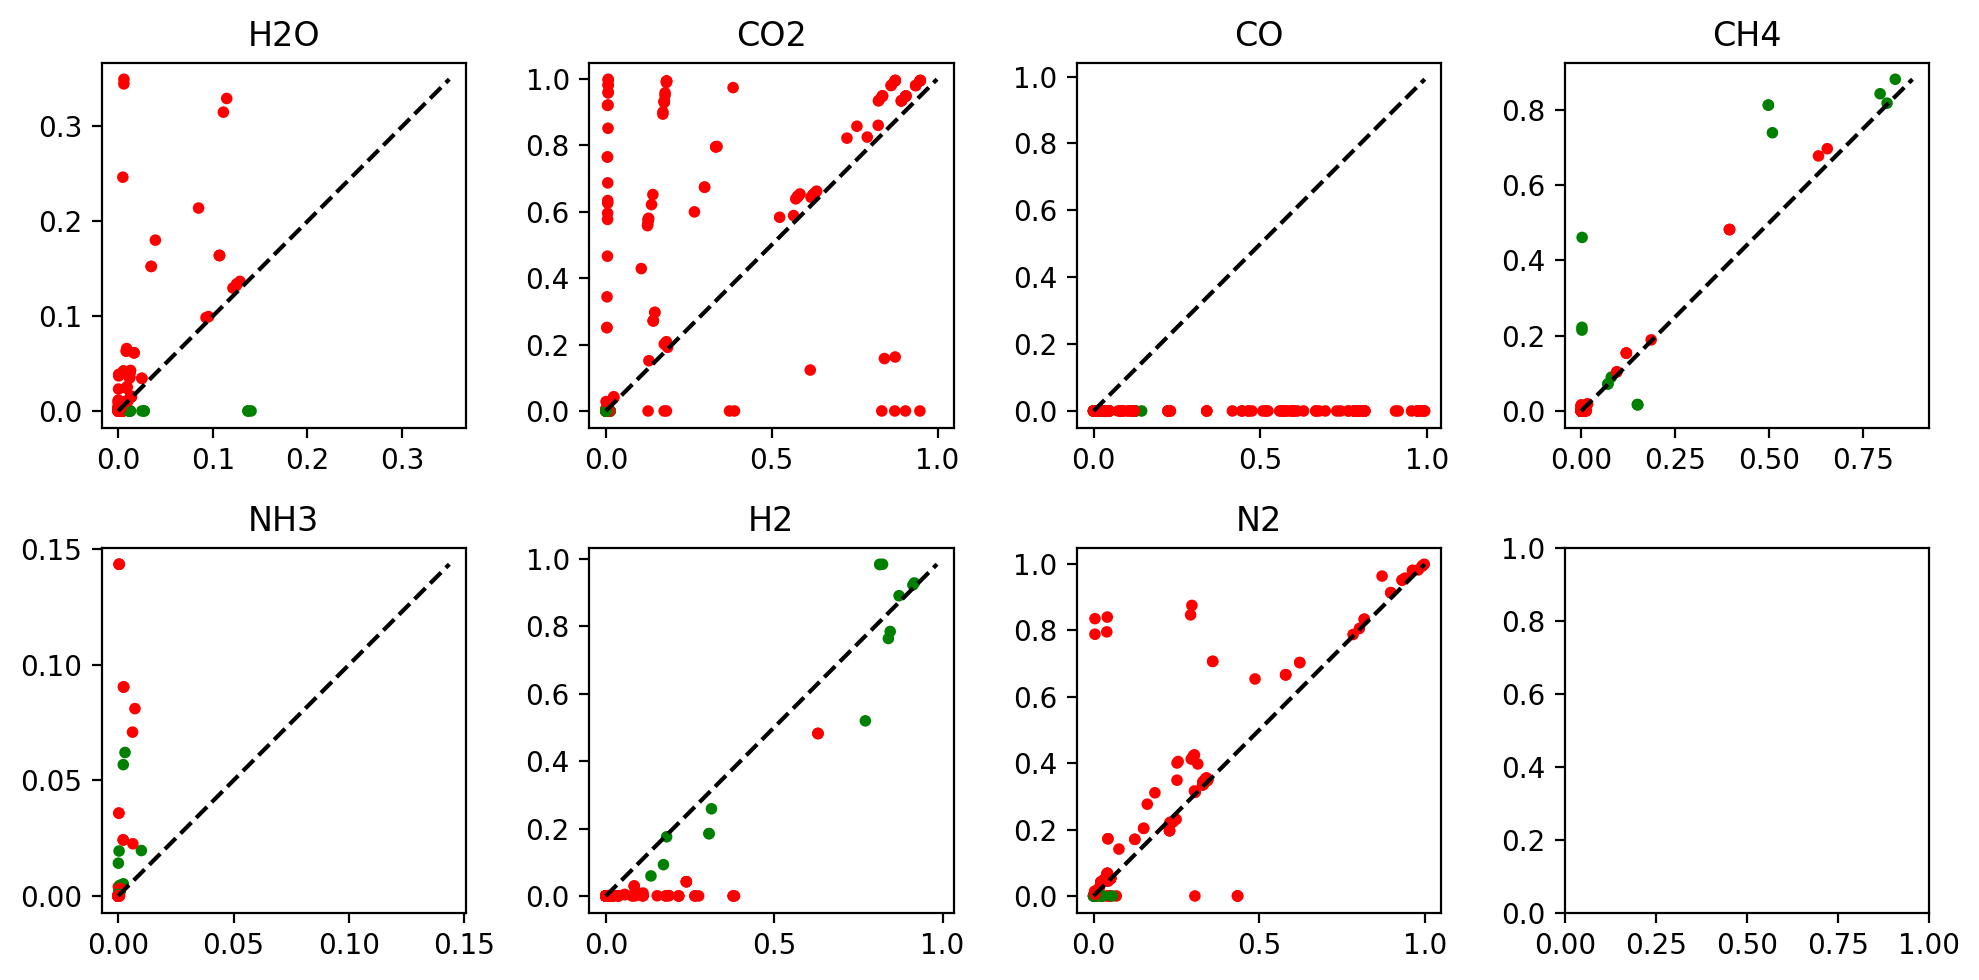

In [18]:
# compare abundances

layer = 0 # (surface layer = 0)
#colors = np.array([run.iterations_read[-1] for run in runs])
#colors = plt.cm.plasma(colors/(np.nanmax(colors)+1))
colors = ['green' if run.iterations_read[-1] > 0 else 'red' for run in runs]

plot_all = True
if plot_all:
    n_mols = len(vmrs.keys())
    n_rows = 2 #np.ceil(np.sqrt(n_mols)).astype('int')
    n_cols = np.ceil(n_mols/n_rows).astype('int')
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(10,5), dpi=200)
    
    for i, mol in enumerate(vmrs.keys()):
        ax = axs[i//n_cols, i%n_cols]
        ggchem_vmr = np.zeros_like(Psurfs)
        for j, run in enumerate(runs):
            if run.final_convergence_status:
                i_mol = run.mol_names.index(mol)
                ggchem_vmr[j] = run.mols_vmr[0, layer, i_mol]

        ax.scatter(vmrs[mol], ggchem_vmr, c=colors, s=10)
        max_vmr = np.max([np.nanmax(vmrs[mol]), np.nanmax(ggchem_vmr)])
        ax.plot(np.linspace(0,max_vmr,100), np.linspace(0,max_vmr,100), "--", color='black')
        #ax.plot(np.linspace(0,1,100), np.linspace(0,1,100), "--", color='black')
        #ax.set_xlim(0,1)
        #ax.set_ylim(0,1)
        ax.set_title(mol)
else:
    mol = 'H2'
    fig, ax = plt.subplots(figsize=(5,5), dpi=200)
    for j, run in enumerate(runs):
            if run.final_convergence_status:
                i_mol = run.mol_names.index(mol)
                ggchem_vmr[j] = run.mols_vmr[0, layer, i_mol]

    ax.scatter(vmrs[mol], ggchem_vmr, c=colors, s=100)
    max_vmr = np.max([np.nanmax(vmrs[mol]), np.nanmax(ggchem_vmr)])
    ax.plot(np.linspace(0,max_vmr,100), np.linspace(0,max_vmr,100), "--", color='grey', zorder=-1)
    ax.set_title(mol)
    ax.set_xlabel('Outgassed VMR')
    ax.set_ylabel('Final Surface VMR')
    
    handles = [plt.scatter([], [], c='green', s=100, label='Converged'), plt.scatter([], [], c='red', s=100, label='Not converged')]
    ax.legend(handles=handles, loc='best')

#set_white(ax)
#increase_size(ax, linewidth=3, fontsize=16, legendloc='best')

fig.tight_layout()

#fig.savefig(f'images/Poster_Venice/ggchem_vmr_comparison_{mol}.svg', format='svg', transparent=True)

converged 144
low P 18
GGchem fails 129


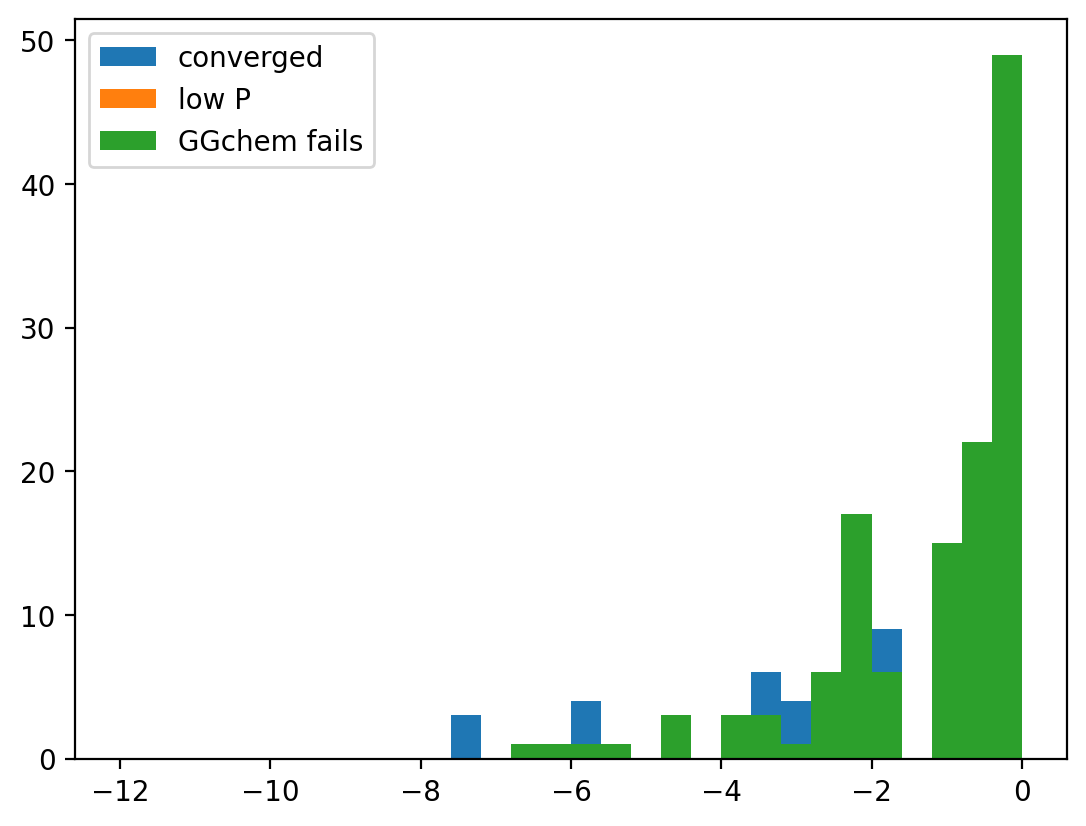

In [19]:
for i,mask in enumerate(masks):
    print(labels[i], np.sum(mask))
    plt.hist(np.log10(vmrs['CO2'][mask]), bins=30, range=(-12, 0), label=labels[i])

plt.legend()

Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=0.1_NtoC=0.01_fO2=-3: 2.3 bar, 82 K
Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=0.1_NtoC=0.1_fO2=-3: 2.4 bar, 83 K
Earth_Tint=50_Tmelt=1000_Hocean=1.0_CtoH=1.0_NtoC=0.01_fO2=-3: 2.4 bar, 83 K
Earth_Tint=50_Tmelt=1000_Hocean=10.0_CtoH=0.1_NtoC=0.01_fO2=-3: 113.2 bar, 250 K
Earth_Tint=50_Tmelt=1000_Hocean=10.0_CtoH=0.1_NtoC=0.01_fO2=0: 53.9 bar, 202 K
Earth_Tint=50_Tmelt=1000_Hocean=10.0_CtoH=0.1_NtoC=0.1_fO2=-3: 114.6 bar, 251 K
Earth_Tint=50_Tmelt=1000_Hocean=10.0_CtoH=0.1_NtoC=0.1_fO2=0: 55.3 bar, 204 K
Earth_Tint=50_Tmelt=1000_Hocean=10.0_CtoH=0.1_NtoC=1.0_fO2=-3: 129.6 bar, 260 K
Earth_Tint=50_Tmelt=1000_Hocean=10.0_CtoH=1.0_NtoC=0.01_fO2=-3: 409.6 bar, 361 K
Earth_Tint=50_Tmelt=1000_Hocean=10.0_CtoH=1.0_NtoC=0.01_fO2=0: 55.3 bar, 204 K
Earth_Tint=50_Tmelt=1000_Hocean=10.0_CtoH=1.0_NtoC=0.1_fO2=-3: 432.7 bar, 367 K
Earth_Tint=50_Tmelt=1000_Hocean=10.0_CtoH=10.0_NtoC=0.01_fO2=-3: 485.1 bar, 379 K
Earth_Tint=50_Tmelt=2000_Hocean=10.0_CtoH=0.1_NtoC

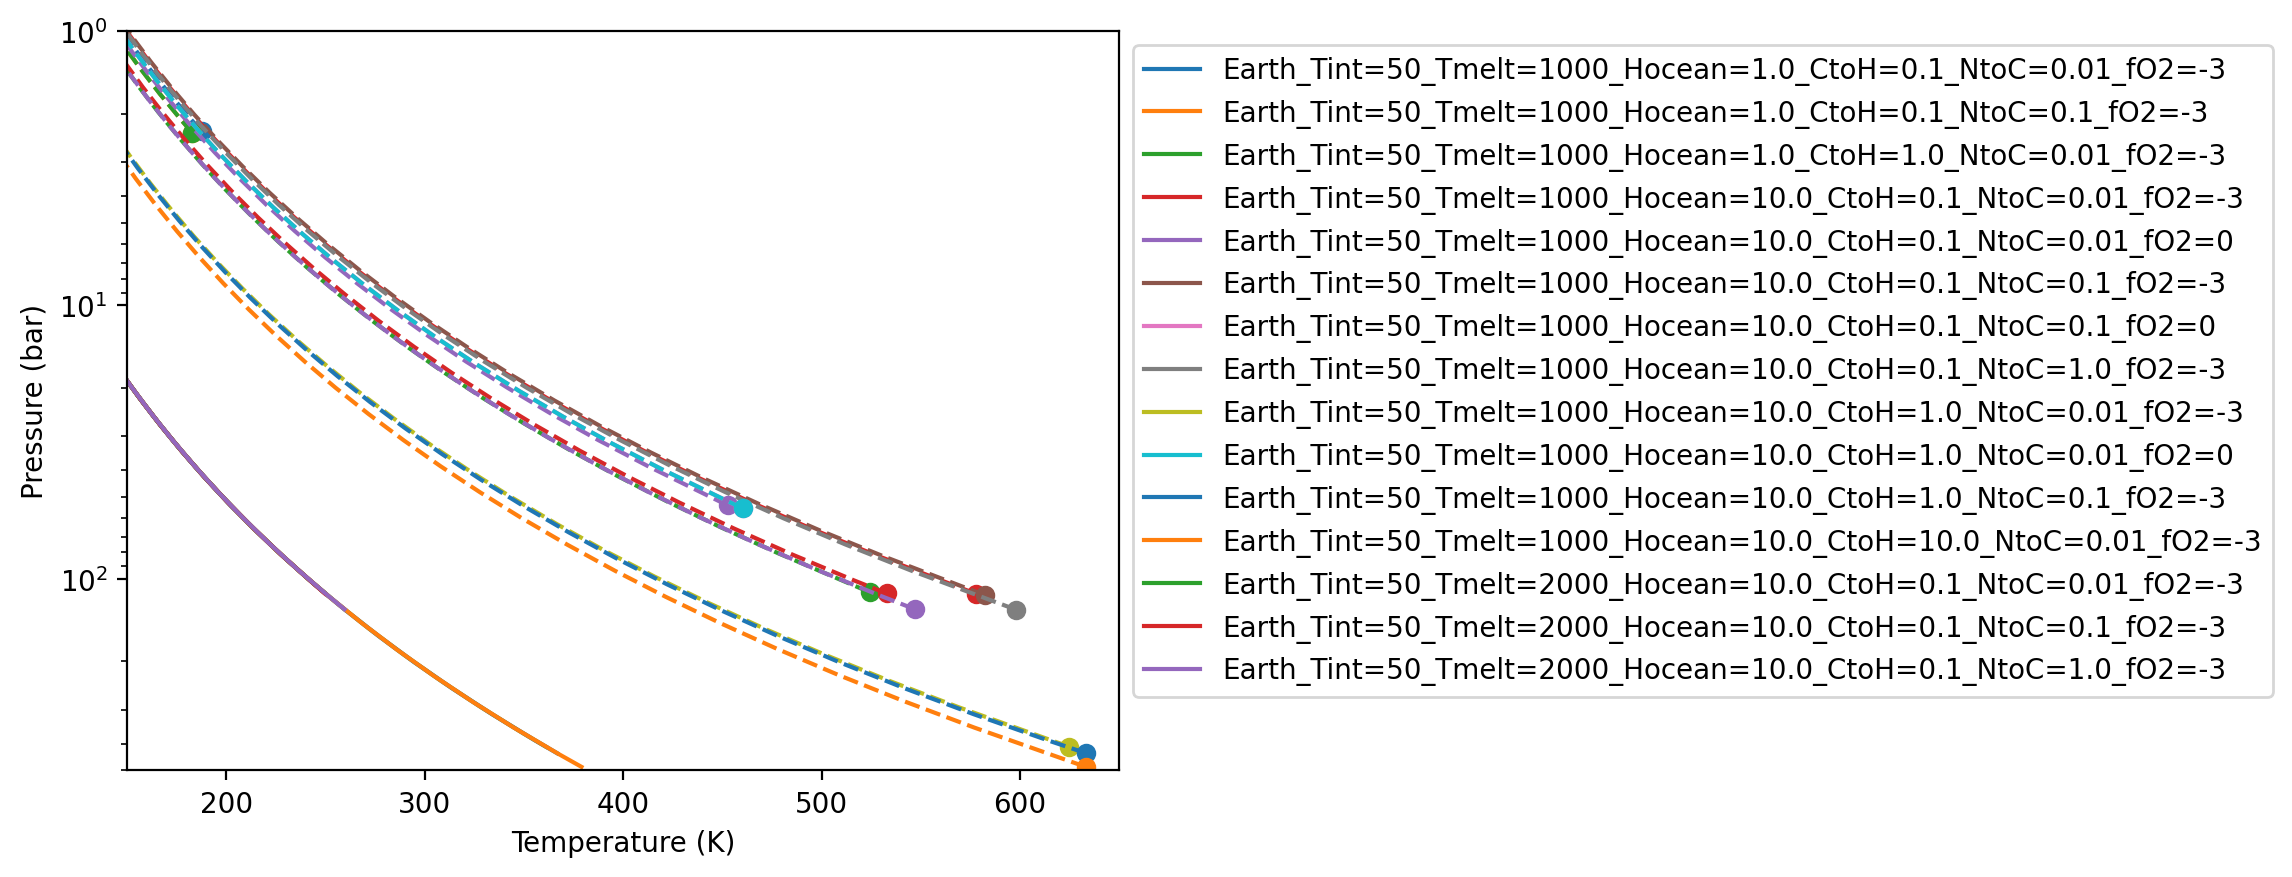

In [34]:
# plot temperature profiles
for i, run in enumerate(runs):
    if run.final_convergence_status:
        if np.all(np.abs(run.temperatures_K[0,:] - 500) > 1e-1):
            print(f'{run.run_name}: {run.pressures_bar[0,0]:.1f} bar, {run.temperatures_K[0,0]:.0f} K')
            line = plt.plot(run.temperatures_K[0,:], run.pressures_bar[0,:], label=run.run_name)
            plt.plot(PTs[i][:,1], PTs[i][:,0], color=line[0].get_color(), linestyle='--')
            plt.plot(PTs[i][0,1], PTs[i][0,0], color=line[0].get_color(), marker='o')

plt.yscale('log')
plt.gca().invert_yaxis()
plt.xlim(150, 650)
plt.ylim(5e2, 1e0)
plt.xlabel('Temperature (K)')
plt.ylabel('Pressure (bar)')
plt.legend(bbox_to_anchor=(1.0, 1.0))
plt.show()

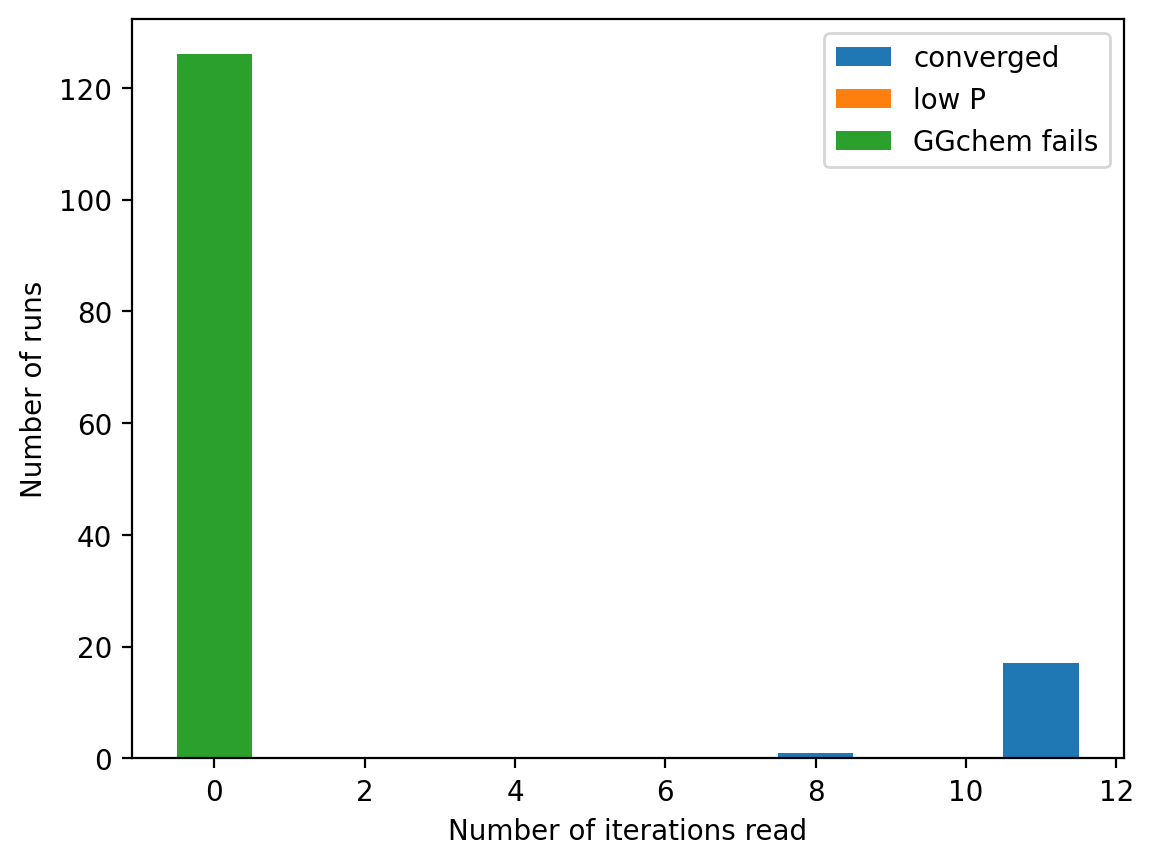

In [11]:
param = 'iterations_read'

param_array = np.array([getattr(run, param) for run in runs])

for i, mask in enumerate(masks):
    plt.hist(param_array[mask], bins=12, range=(-0.5, 11.5), label=labels[i])
plt.xlabel('Number of iterations read')
plt.ylabel('Number of runs')
plt.legend()
plt.show()

162 162
[nan, nan, nan, nan, nan, nan, nan, 261.14, 268.445, nan, 280.851, 374.644, nan, 283.689, 375.246, 255.302, 299.72, 381.731, nan, 283.689, 461.302, 255.302, 299.72, 462.742, 358.913, 348.26, 483.102, nan, nan, nan, nan, nan, nan, nan, nan, 268.099, 268.263, 324.985, 373.201, 268.622, 325.782, 373.759, 272.754, 332.874, 380.307, 346.697, 443.732, 461.012, 348.305, 445.365, 462.436, 365.507, 474.706, 483.138, 513.822, 418.196, 437.707, 552.022, 434.677, 439.215, 633.779, 493.621, 450.731, 552.022, 434.677, 524.122, 633.779, 493.621, 528.231, 931.528, 659.674, 543.93, 633.779, 493.621, 739.774, 931.528, 659.674, 741.024, 1339.2, 894.703, 783.294, 382.957, 416.394, 436.517, 396.533, 418.897, 437.633, 428.971, 434.363, 448.672, 513.228, 506.718, 523.776, 538.173, 511.716, 527.705, 563.017, 536.297, 544.349, 706.749, 706.401, 747.162, 706.679, 724.432, 762.776, 761.782, 746.676, 780.945, 1743.15, 1450.86, 1109.5, 1803.76, 1575.1, 1134.93, 1890.32, 1732.36, 1211.5, 1625.55, 1575.06, 1

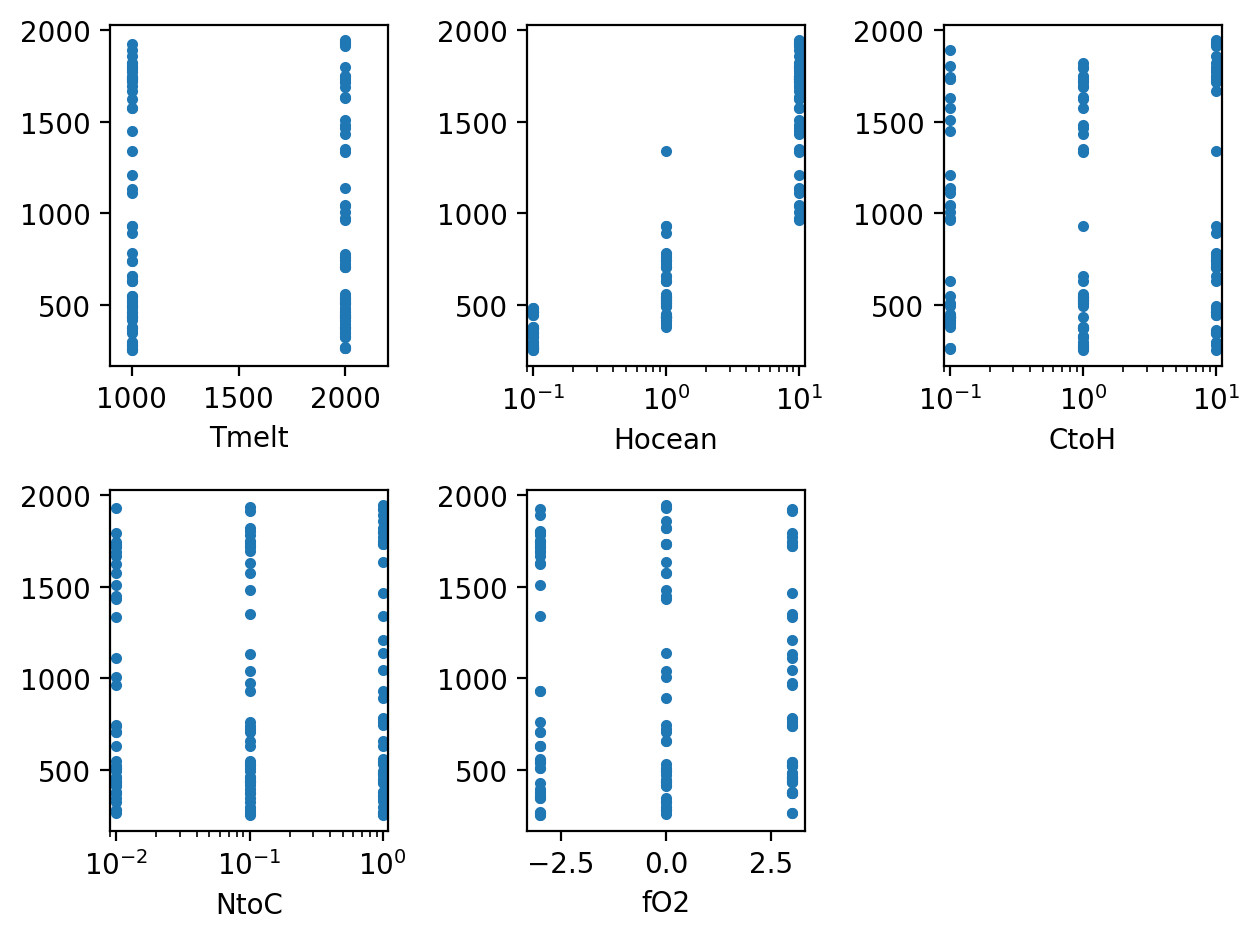

In [31]:
fig, ax = plt.subplots(2,3)
ax = ax.flatten()

print(len(runs), len(PTs))
#y_data = [run.temperatures_K[0,0] if abs(run.temperatures_K[0,0] - 500) > 1e-1 else np.nan for run in runs]
y_data = [PTs[j][0,1] for j in range(len(PTs))]
print(y_data)

for i,p in enumerate(param_grid):
    ax[i].plot(p, y_data, '.')
    if param_log[i]:
        ax[i].set_xscale('log')
    ax[i].set_xlim(p.min()*(1-0.1*np.sign(p.min())), p.max()*(1+0.1*np.sign(p.max())))
    #ax[i].set_yscale('log')
    ax[i].set_xlabel(var_param_names[i])
    #ax[i].set_ylabel('Pressure (bar)')

# delete empty subplots
ax[-1].remove()

fig.tight_layout()